In [1]:
import re
import pandas as pd
from pathlib import Path

poses_dir = Path("poses")
targets_dir = poses_dir / "targets"
target_affinities = []

def parse_log_file(log_file):
    with open(log_file) as f:
        lines = f.readlines()
    
    parsing_table = False
    affinities = []
    
    for line in lines:
        if re.match(r"mode\s*\|.*affinity", line):
            parsing_table = True
            continue
        if parsing_table:
            if line.strip() == "" or line.startswith("-----"):
                continue
            # Extract numbers
            numbers = re.findall(r"[-+]?\d*\.\d+|\d+", line)
            if len(numbers) == 4:
                mode_idx, affinity, rmsd_lb, rmsd_ub = numbers
                affinities.append(float(affinity))
    
    return affinities

for target in targets_dir.glob("*"):
    target_name = target.stem
    for activity in ('active', 'inactive'):
        pdbqts = (targets_dir / target_name / activity).glob("*.pdbqt")
        for pdbqt in pdbqts:
            affinities = parse_log_file(pdbqt.with_suffix(".log"))
            target_affinities.append({
                "target": target_name,
                "approach": activity,
                "best_affinity": affinities[0],
                "all_affinities": affinities
            })

target_affinities_df = pd.DataFrame(target_affinities)
print(target_affinities_df.shape)
print(target_affinities_df["target"].value_counts())

target_affinities_df.sample(10)

(2000, 4)
target
D2R       400
AChE      400
MAOB      400
D3R       400
_5HT2A    400
Name: count, dtype: int64


,target,approach,best_affinity,all_affinities
1477,D3R,inactive,-8.6681,"[-8.6681, -8.3239, -8.3217, -8.2929, -8.1465, ..."
1739,_5HT2A,active,-10.5713,"[-10.5713, -10.0961, -10.0396, -9.9762, -9.969..."
441,AChE,active,-12.5453,"[-12.5453, -11.2678, -10.8322, -10.6721, -10.4..."
1433,D3R,inactive,-10.3139,"[-10.3139, -10.0017, -9.6094, -9.2423, -9.1042..."
1898,_5HT2A,inactive,-7.4760,"[-7.476, -7.344, -7.3177, -7.225, -7.2155, -7...."
1357,D3R,active,-7.8240,"[-7.824, -7.7979, -7.6289, -7.6153, -7.549, -7..."
161,D2R,active,-8.6516,"[-8.6516, -8.6501, -8.566, -8.5388, -8.5286, -..."
400,AChE,active,-12.3197,"[-12.3197, -12.2267, -12.1868, -11.6556, -11.5..."
542,AChE,active,-11.7727,"[-11.7727, -11.6902, -11.5038, -11.4539, -11.4..."
1070,MAOB,inactive,-4.9265,"[-4.9265, -4.2989, -4.1848, -4.1778, -4.1704, ..."


In [2]:
target_affinities_df.sort_values(
    ["target", "approach"], ascending=False
).groupby(["target", "approach"]).agg(
    {"best_affinity": "mean"}
).unstack().style.background_gradient(cmap="RdYlGn_r", axis=1).format(precision=2)  # .sort_values("best_affinity", ascending=False)

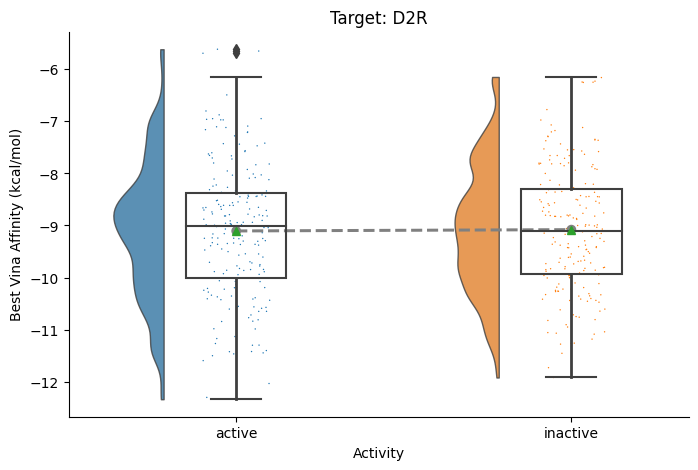

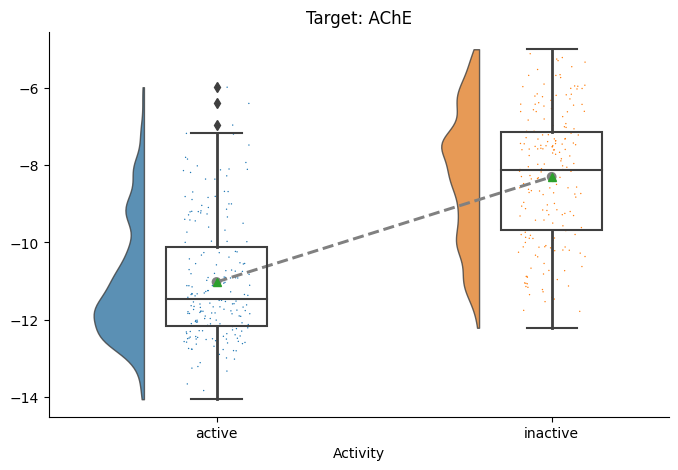

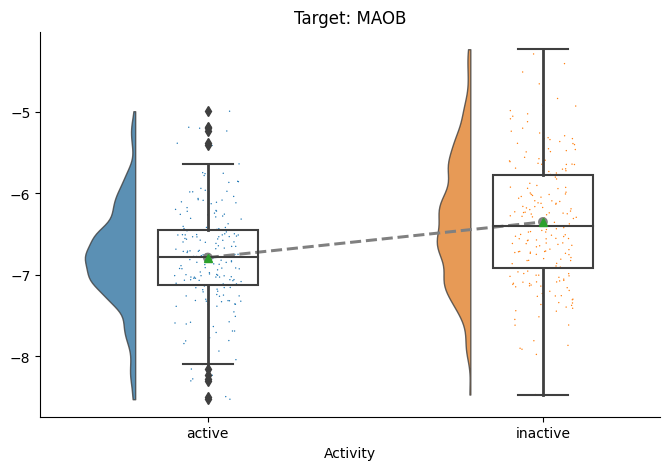

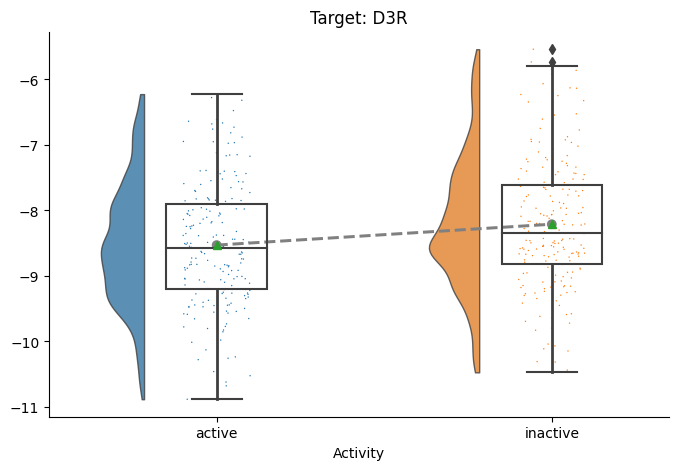

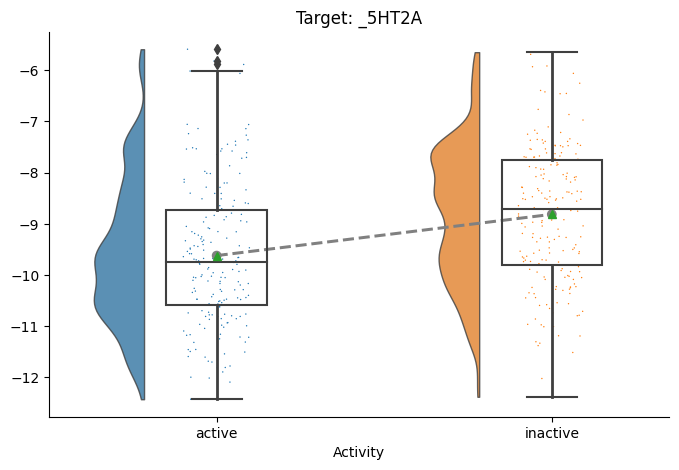

In [3]:
import matplotlib.pyplot as plt
import ptitprince as pt
import seaborn as sns

targets = target_affinities_df['target'].unique()
n_targets = len(targets)

pal=list(sns.color_palette("tab10"))
# fig, axes = plt.subplots(n_targets, 1, figsize=(8, 5 * n_targets))
# if n_targets == 1:
#     axes = [axes]

for i, target in enumerate(targets):
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    # ax = axes[0]
    target_df = target_affinities_df[target_affinities_df['target'] == target]
    pt.RainCloud(
        x="approach",
        y="best_affinity",
        # hue="approach",
        data=target_df,
        # palette="Set2",
        palette=pal,
        # bw=.5,
        width_viol=.3,
        width_box=.3,
        orient="v",  # or "v"
        # move=0.15,
        linewidth=1,
        alpha=0.8,
        ax=ax,
        dodge=True,
        pointplot=True, point_size=1.0, linecolor='grey', point_linestyles='--', point_scale=0.8,
        box_showmeans=True
        # bw=.1, ax=ax, palette=pal, 
        #          orient="h", alpha=0.9, pointplot=True, point_size=0.8, linecolor='grey', 
        #          point_linestyles='--', point_scale=0.4

    )
    ax.set_title(f"Target: {target}")
    ax.set_xlabel("Activity")
    if i == 0:
        ax.set_ylabel("Best Vina Affinity (kcal/mol)")
    else:
        ax.set_ylabel("")
    # ax.legend().set_title("Activity")
    # ax.legend().set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.show()

# fig.suptitle("Activity Distribution of Best Affinities by Target")
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.show()

In [4]:
baselines = ["25-epoch", "DeepLig", "MTMol-GPT", "POLYGON"]
conditions = ["alzheimer",  "schizophrenia", "parkinson"]
results = []

for baseline in baselines:
    log_files = (poses_dir / baseline).rglob("*.log")

    for log_file in log_files:
        # Extract ligand and receptor from filename
        try:
            approach, disease, idx, _, receptor_name = log_file.stem.replace("_5HT2A", "5HT2A").split("_")
        except:
            print(f"Error: {log_file.stem}")
            print(log_file.stem.replace("_5HT2A", "5HT2A").split("_"))

        affinities = parse_log_file(log_file)
        
        if affinities:
            results.append({
                "approach": approach,
                "target": receptor_name,
                "disease": disease,
                "best_affinity": affinities[0],
                "all_affinities": affinities
            })

baselines_affinities = pd.DataFrame(results)
print(baselines_affinities.shape)
print(baselines_affinities["approach"].value_counts())
baselines_affinities.head()

(4108, 5)
approach
25-epoch     1200
MTMol-GPT    1200
POLYGON      1200
DeepLig       508
Name: count, dtype: int64


,approach,target,disease,best_affinity,all_affinities
0,25-epoch,D2R,parkinson,-9.3044,"[-9.3044, -8.4227, -8.2464, -8.2052, -8.0674, ..."
1,25-epoch,D3R,parkinson,-6.9388,"[-6.9388, -6.7634, -6.7178, -6.596, -6.5951, -..."
2,25-epoch,D2R,parkinson,-7.2724,"[-7.2724, -6.9117, -6.8826, -6.2187, -6.1458, ..."
3,25-epoch,D3R,parkinson,-6.4097,"[-6.4097, -6.3201, -6.3057, -6.2904, -6.1935, ..."
4,25-epoch,D2R,parkinson,-9.8972,"[-9.8972, -9.8034, -9.6662, -9.6302, -9.6214, ..."


In [5]:
condition_dfs = dict()
condition_to_targets = {
    "alzheimer": ["AChE", "MAOB"],
    "schizophrenia": ["_5HT2A", "D2R"],
    "parkinson": ["D2R", "D3R"]
}

for condition in conditions:
    condition_dfs[condition] = baselines_affinities[
        baselines_affinities["disease"] == condition
    ]
    targets = condition_to_targets[condition]
    condition_dfs[condition] = pd.concat([
        condition_dfs[condition],
        target_affinities_df[target_affinities_df["target"].isin(targets)]
    ]).replace({
        "25-epoch": "CoMPO-GPT",
        "active": "Active",
        "inactive": "Inactive",
        "_5HT2A": "5-HT2AR",
        "5HT2A": "5-HT2AR",
        "MAOB": "MAO-B",
    })

print(condition_dfs["schizophrenia"]["approach"].value_counts())
print(condition_dfs["schizophrenia"]["target"].value_counts())

approach
CoMPO-GPT    400
MTMol-GPT    400
POLYGON      400
Active       400
Inactive     400
DeepLig        2
Name: count, dtype: int64
target
D2R        1001
5-HT2AR    1001
Name: count, dtype: int64


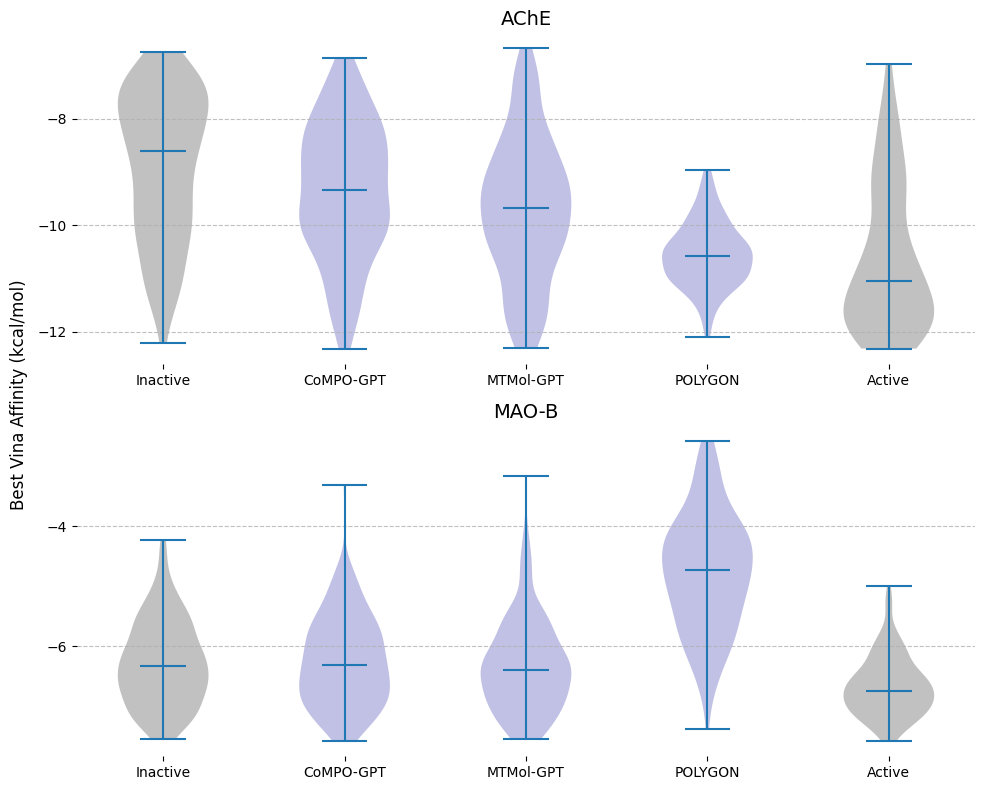

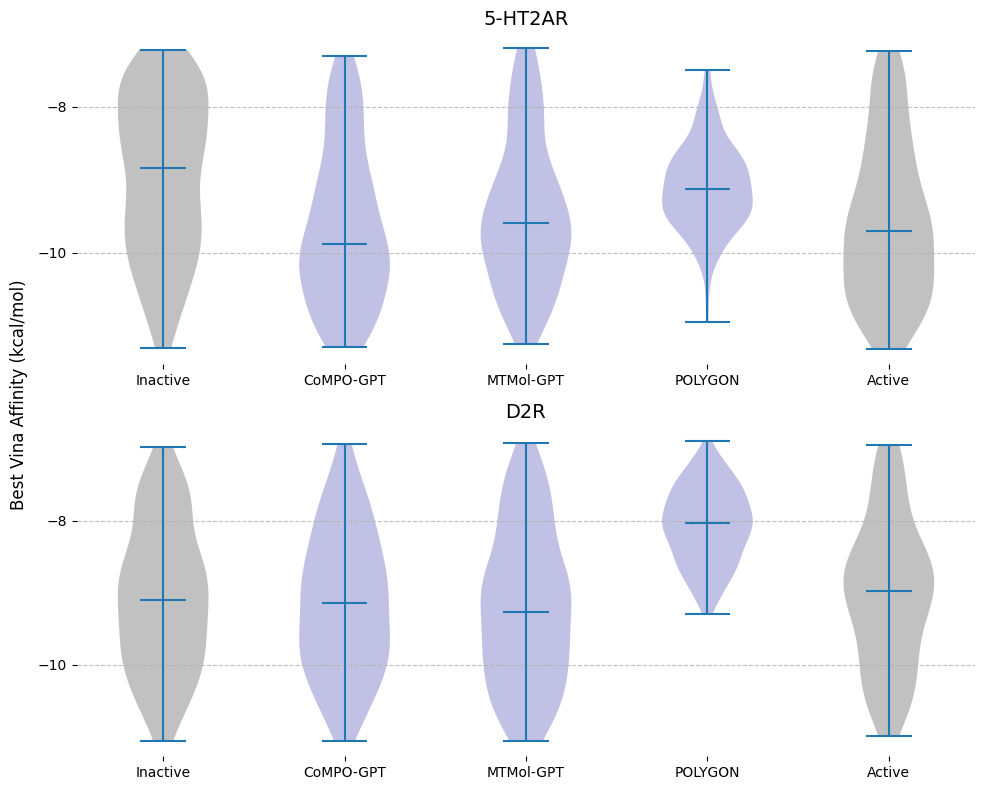

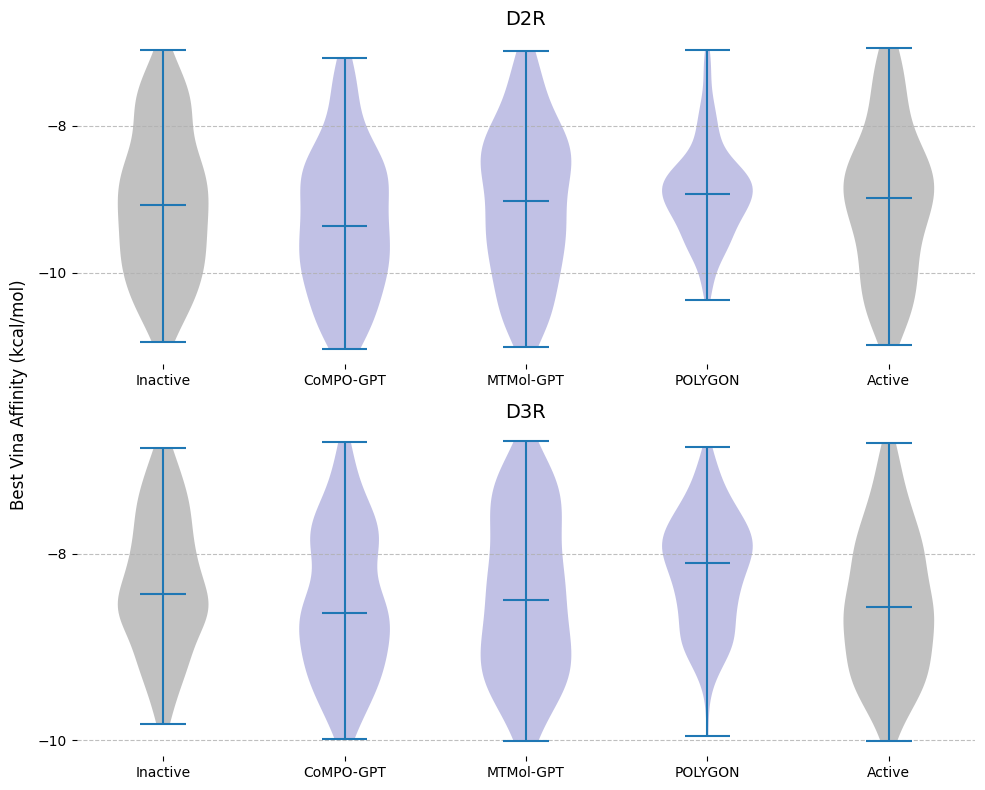

In [6]:
# Plot a separate sns.violinplot chart for each condition comparing the baselines, and the active/inactive compounds
order = ["Inactive", "CoMPO-GPT", "DeepLig", "MTMol-GPT", "POLYGON", "Active"]
order = ["Inactive", "CoMPO-GPT", "MTMol-GPT", "POLYGON", "Active"]

# Map original target names to their replaced names
target_replacements = {
    "_5HT2A": "5-HT2AR",
    "5HT2A": "5-HT2AR",
    "MAOB": "MAO-B"
}

pal = list(sns.color_palette("tab10"))

def drop_outliers(df):
    return df[(df["best_affinity"] < df["best_affinity"].quantile(0.95)) & (df["best_affinity"] > df["best_affinity"].quantile(0.05))]

for condition in conditions:
    targets = condition_to_targets[condition]
    # Map targets to their replaced names if they were replaced
    mapped_targets = [target_replacements.get(target, target) for target in targets]

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharey=False)

    for i, target in enumerate(mapped_targets):
        ax = axes[i]
        condition_df = condition_dfs[condition]

        # Filter by target and approach
        target_df = condition_df[
            (condition_df["target"] == target) & 
            (condition_df["approach"].isin(order))
        ].copy()

        # Order according to order
        target_df["approach"] = pd.Categorical(target_df["approach"], categories=order, ordered=True)
        target_df = target_df.sort_values("approach")

        target_df = drop_outliers(target_df)

        affine_groups = [target_df[target_df["approach"] == approach]["best_affinity"].dropna().values
                         for approach in order]
        # Only keep approaches that actually have values to avoid empty plots
        affine_groups_plot = []
        order_plot = []
        for i, arr in enumerate(affine_groups):
            if len(arr) > 20:
                affine_groups_plot.append(arr)
                order_plot.append(order[i])
        # The xtick position has to match the x in violinplot
        positions = list(range(1, len(order_plot) + 1))
        parts = ax.violinplot(
            affine_groups_plot,
            positions=positions,
            showmeans=False,
            showextrema=True,
            showmedians=True
        )
        # Optionally style the violin color
        for i, pc in enumerate(parts['bodies']):
            if (i == 0) or (i == len(order_plot) - 1):
                pc.set_facecolor('#333333')
                pc.set_alpha(0.3)
                continue

            pc.set_facecolor('#3333aa')
            pc.set_alpha(0.3)
        
        # Set x ticks to the used approaches
        ax.set_xticks(positions)
        ax.set_xticklabels(order_plot, rotation=0)
        # Add horizontal grid lines
        from matplotlib.ticker import MultipleLocator
        ax.yaxis.set_major_locator(MultipleLocator(2))
        ax.yaxis.grid(True, which='major', linestyle='--', alpha=0.8)

        ax.set_title(f"{target}", fontsize=14)
        ax.set_xlabel(None)
        ax.set_ylabel("")
        # ax.legend().set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        # Set x-axis order
        ax.set_xticklabels(order, rotation=0,) # ha='right')

    # Set a single y label for both axes
    fig.supylabel("Best Vina Affinity (kcal/mol)", fontsize=12)
    # fig.suptitle(f"Condition: {condition.capitalize()}", 
                #   fontsize=16, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

In [7]:
# Compute statistics (mean, median, std) for each condition, target, and approach
order = ["Inactive", "CoMPO-GPT", "DeepLig", "MTMol-GPT", "POLYGON", "Active"]

# Map original target names to their replaced names
target_replacements = {
    "_5HT2A": "5-HT2AR",
    "5HT2A": "5-HT2AR",
    "MAOB": "MAO-B"
}

# Prepare data for statistics
stats_data = []
for condition in conditions:
    targets = condition_to_targets[condition]
    mapped_targets = [target_replacements.get(target, target) for target in targets]
    
    for target in mapped_targets:
        condition_df = condition_dfs[condition]
        target_df = condition_df[
            (condition_df["target"] == target) & 
            (condition_df["approach"].isin(order))
        ]
        
        for approach in order:
            approach_data = target_df[target_df["approach"] == approach]["best_affinity"]
            if len(approach_data) > 0:
                stats_data.append({
                    "condition": condition.capitalize(),
                    "target": target,
                    "approach": approach,
                    "mean": approach_data.mean(),
                    "median": approach_data.median(),
                    "std": approach_data.std()
                })

stats_df = pd.DataFrame(stats_data)

# Create three separate dataframes: mean, median, and std
mean_df = stats_df.pivot_table(
    index=["condition", "target"],
    columns="approach",
    values="mean",
    aggfunc="first"
).reindex(columns=order).drop(columns=["DeepLig"])

median_df = stats_df.pivot_table(
    index=["condition", "target"],
    columns="approach",
    values="median",
    aggfunc="first"
).reindex(columns=order)

std_df = stats_df.pivot_table(
    index=["condition", "target"],
    columns="approach",
    values="std",
    aggfunc="first"
).reindex(columns=order)

# Create a combined dataframe with mean ± std
mean_std_df = mean_df.copy()
for col in mean_std_df.columns:
    if col in std_df.columns:
        mean_std_df[col] = mean_std_df[col].apply(lambda x: f"{x:.2f}") + " ± " + std_df[col].apply(lambda x: f"{x:.1f}")

print(mean_std_df.to_latex())

# Display the three dataframes
print("=" * 80)
print("MEAN Best Vina Affinity (kcal/mol)")
print("=" * 80)
display(mean_df.style.background_gradient(cmap="Blues", axis=1).format(precision=2))

print("\n" + "=" * 80)
print("MEDIAN Best Vina Affinity (kcal/mol)")
print("=" * 80)
display(median_df.style.background_gradient(cmap="Blues", axis=1).format(precision=2))

print("\n" + "=" * 80)
print("STANDARD DEVIATION Best Vina Affinity (kcal/mol)")
print("=" * 80)
display(std_df)

\begin{tabular}{lllllll}
\toprule
 & approach & Inactive & CoMPO-GPT & MTMol-GPT & POLYGON & Active \\
condition & target &  &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{Alzheimer} & AChE & -8.30 ± 1.7 & -9.35 ± 1.4 & -9.72 ± 1.4 & -10.55 ± 0.6 & -11.02 ± 1.6 \\
 & MAO-B & -6.35 ± 0.8 & -6.40 ± 0.9 & -6.37 ± 0.9 & -3.02 ± 3.8 & -6.79 ± 0.6 \\
\cline{1-7}
\multirow[t]{2}{*}{Parkinson} & D2R & -9.08 ± 1.2 & -9.35 ± 1.3 & -9.04 ± 1.3 & -8.66 ± 1.0 & -9.11 ± 1.3 \\
 & D3R & -8.21 ± 1.0 & -8.61 ± 1.0 & -8.44 ± 1.1 & -8.17 ± 0.6 & -8.53 ± 0.9 \\
\cline{1-7}
\multirow[t]{2}{*}{Schizophrenia} & 5-HT2AR & -8.82 ± 1.3 & -9.70 ± 1.3 & -9.40 ± 1.3 & -9.07 ± 0.6 & -9.62 ± 1.4 \\
 & D2R & -9.08 ± 1.2 & -9.21 ± 1.3 & -9.14 ± 1.3 & -7.95 ± 0.7 & -9.11 ± 1.3 \\
\cline{1-7}
\bottomrule
\end{tabular}

MEAN Best Vina Affinity (kcal/mol)



MEDIAN Best Vina Affinity (kcal/mol)



STANDARD DEVIATION Best Vina Affinity (kcal/mol)


approach               Inactive  CoMPO-GPT   DeepLig  MTMol-GPT   POLYGON   
condition     target                                                        
Alzheimer     AChE     1.693982   1.442451  0.664511   1.442332  0.613434  \
              MAO-B    0.772608   0.860968  1.973062   0.863689  3.789226   
Parkinson     D2R      1.206931   1.255223  0.822518   1.256264  1.002538   
              D3R      1.001236   0.998155  0.869526   1.099123  0.603482   
Schizophrenia 5-HT2AR  1.333312   1.261943       NaN   1.322207  0.647896   
              D2R      1.206931   1.265325       NaN   1.343166  0.662136   

approach                 Active  
condition     target             
Alzheimer     AChE     1.575775  
              MAO-B    0.617618  
Parkinson     D2R      1.301351  
              D3R      0.945869  
Schizophrenia 5-HT2AR  1.377533  
              D2R      1.301351

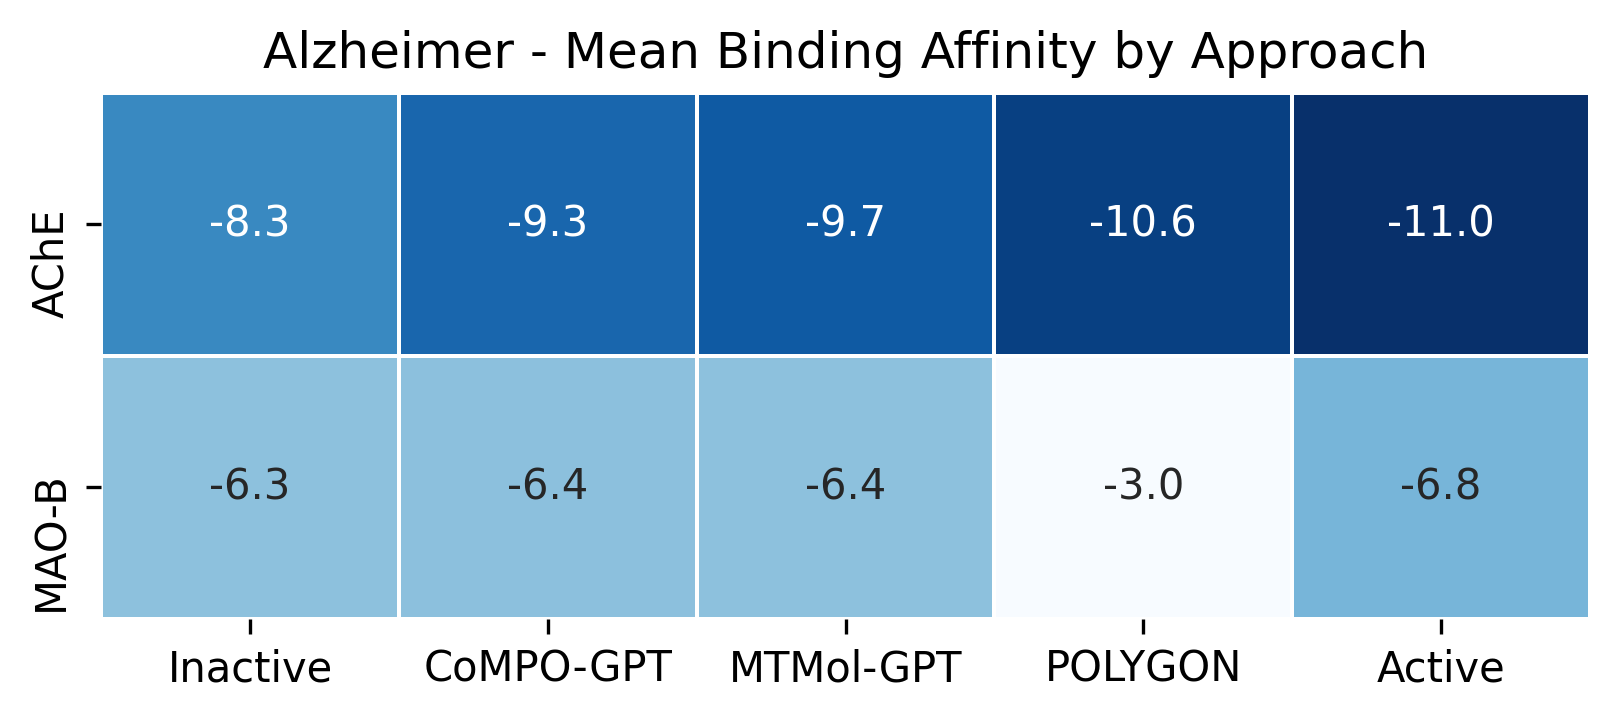

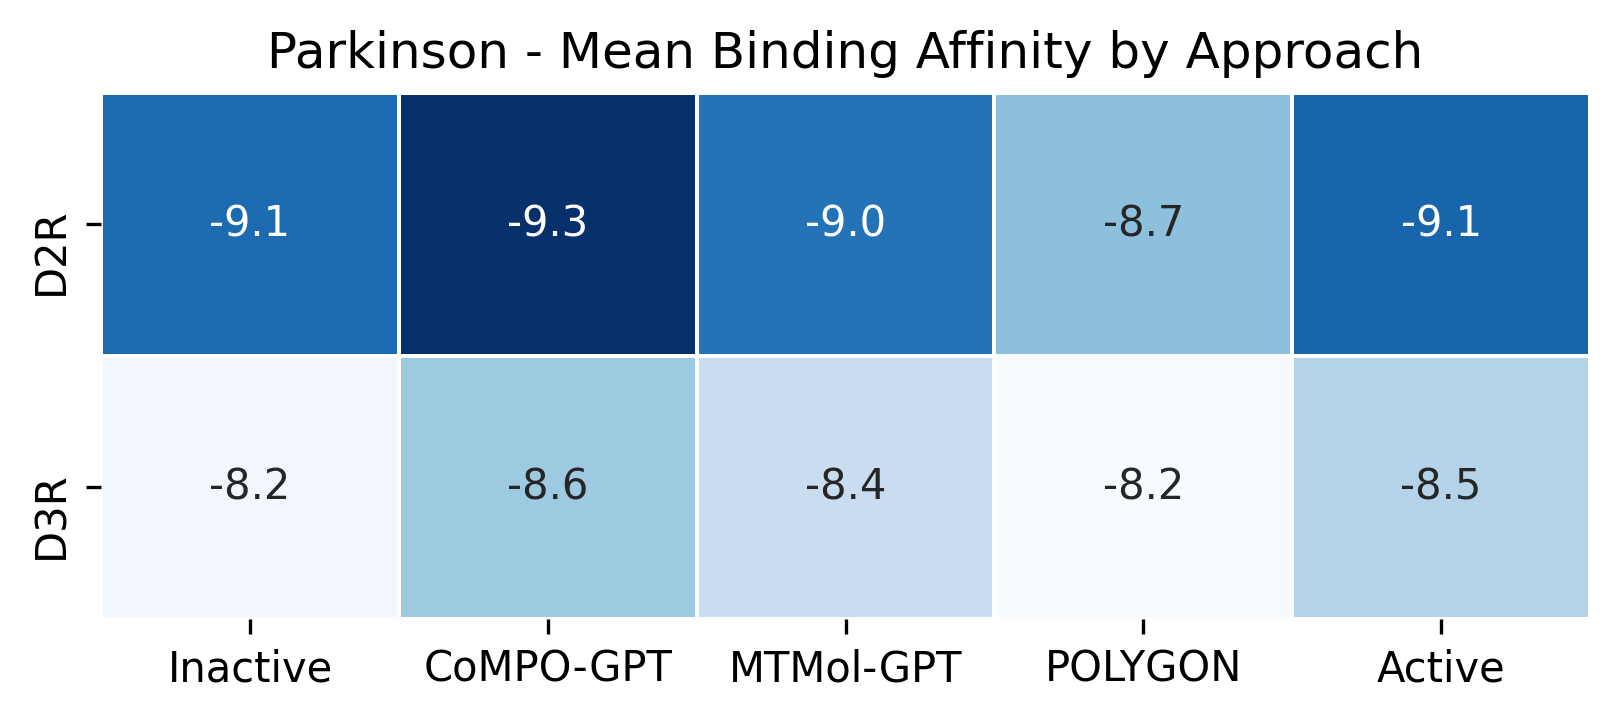

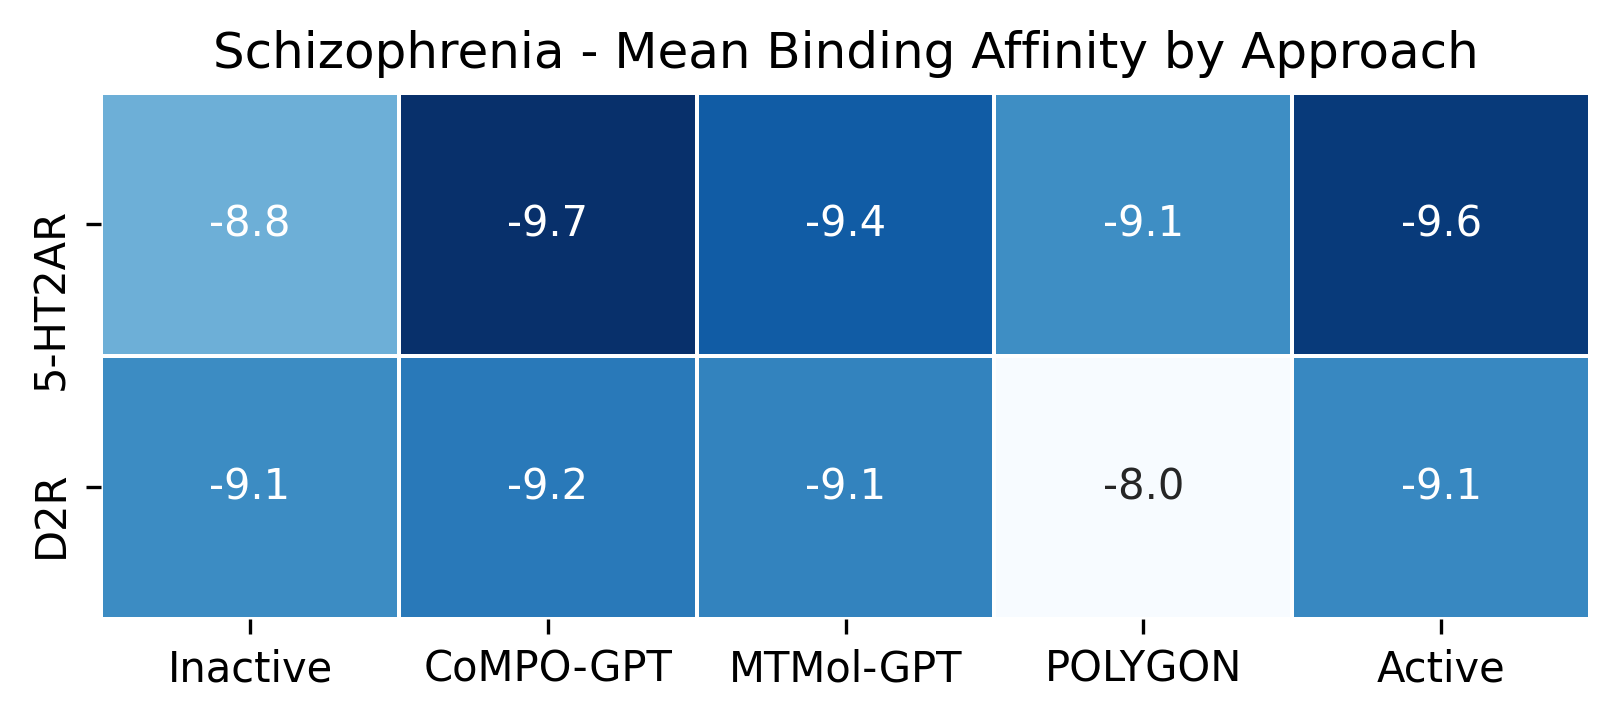

In [8]:
# Plot the mean binding affinity for each approach as a sns heatmap with Blues pallete
heatmap_order = ["Inactive", "CoMPO-GPT", "MTMol-GPT", "POLYGON", "Active"]

for condition, condition_df in mean_df.groupby(level="condition"):
    # Drop the condition level to leave targets on rows and order approaches on columns
    condition_matrix = (
        condition_df.droplevel("condition")
        .reindex(columns=heatmap_order)
        .dropna(how="all")
    )

    if condition_matrix.empty:
        continue

    plt.figure(figsize=(5.5, 1.25 * len(condition_matrix)), dpi=300)
    sns.heatmap(
        condition_matrix,
        cmap="Blues_r",
        annot=True,
        fmt=".1f",
        linewidths=0.5,
        linecolor="white",
        cbar=False
    )
    plt.title(f"{condition} - Mean Binding Affinity by Approach")
    plt.xlabel(None)
    plt.ylabel(None)
    plt.tight_layout()
    plt.show()